# Tutorial 9 — Several suppliers, one quality measure

## 1. Problem / context

Incoming resin is bought from three suppliers. Each laboratory sample is one observational unit; the response is impurity concentration in mg/kg. Operations asks whether mean impurity differs among suppliers A, B, and C, and *which* suppliers differ.

The data are `data/supplier_impurity.csv`. Brooks Chapter 9 is the theory: why many unadjusted $t$-tests are a poor default, the ANOVA table, diagnostics on **within-group errors**, Tukey HSD, and $\eta^2$.

A collection of pairwise $t$-tests at level 0.05 inflates the chance of at least one false difference. One-way ANOVA asks the global question first.

## 2. What we will compute

$$
H_0:\mu_A=\mu_B=\mu_C
\qquad\text{versus}\qquad
H_1:\text{at least one mean differs}.
$$

$F$ compares **between-supplier** variation with **within-supplier** variation. A large $F$ is evidence against a single common mean; it does not name the pair.

Independence is a **design** assumption. Approximate error shape and common spread are diagnosed from group plots, residual plots, and a QQ-plot of **residuals**, not from a QQ-plot of the pooled raw impurity values.

Classical one-way ANOVA is appropriate when a common within-group variance is credible. **Welch's** one-way ANOVA is the practical alternative when independent groups have materially unequal spreads. Tukey HSD belongs with the classical model. Do not follow Welch's ANOVA with ordinary Tukey intervals; a compatible pairwise method such as Games–Howell is not in the course libraries, so we will not fake that combination.

After a relevant significant classical omnibus test, Tukey HSD gives multiplicity-adjusted pairwise $p$-values and simultaneous confidence intervals. A non-significant pair does **not** establish equal means.

$\eta^2=SS_{\mathrm{between}}/SS_{\mathrm{total}}$ is a descriptive fraction of observed squared variation. It is not causation and not the probability that supplier determines a sample.

## 3. Python implementation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import probplot
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.oneway import anova_oneway

candidates = [Path("data"), Path("../data"), Path.cwd() / "data"]
DATA = next(p for p in candidates if p.exists())
df = pd.read_csv(DATA / "supplier_impurity.csv")
print(df.head())
print(df["supplier"].value_counts().sort_index())


   sample_id supplier  impurity_mg_kg
0          1        A          12.253
1          2        A          13.863
2          3        A          11.979
3          4        A          12.274
4          5        A          12.443
supplier
A    24
B    24
C    24
Name: count, dtype: int64


In [2]:
summary = (
    df.groupby("supplier")["impurity_mg_kg"]
    .agg(n="size", mean="mean", std="std")
)
print(summary)


           n       mean       std
supplier                         
A         24  11.817333  1.113975
B         24  15.015167  1.319419
C         24  12.091667  1.276602


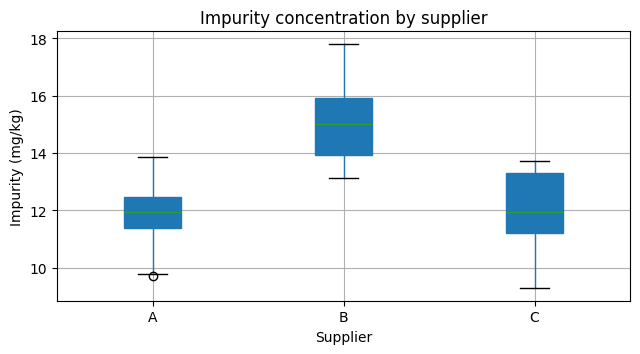

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
df.boxplot(column="impurity_mg_kg", by="supplier", ax=ax, patch_artist=True)
ax.set_xlabel("Supplier")
ax.set_ylabel("Impurity (mg/kg)")
ax.set_title("Impurity concentration by supplier")
plt.suptitle("")
plt.tight_layout()
plt.show()


Fit the classical one-way model and read the ANOVA table.


In [4]:
model = ols("impurity_mg_kg ~ C(supplier)", data=df).fit()
tbl = anova_lm(model, typ=2)
print(tbl)
ss_between = tbl.loc["C(supplier)", "sum_sq"]
ss_resid = tbl.loc["Residual", "sum_sq"]
eta2 = ss_between / (ss_between + ss_resid)
print(f"F = {tbl.loc['C(supplier)', 'F']:.3f}")
print(f"p = {tbl.loc['C(supplier)', 'PR(>F)']:.4g}")
print(f"eta-squared = {eta2:.3f}")


                 sum_sq    df          F        PR(>F)
C(supplier)  150.785992   2.0  49.046505  5.600579e-14
Residual     106.064984  69.0        NaN           NaN
F = 49.047
p = 5.601e-14
eta-squared = 0.587


### Diagnostics: residuals, not the pooled raw response


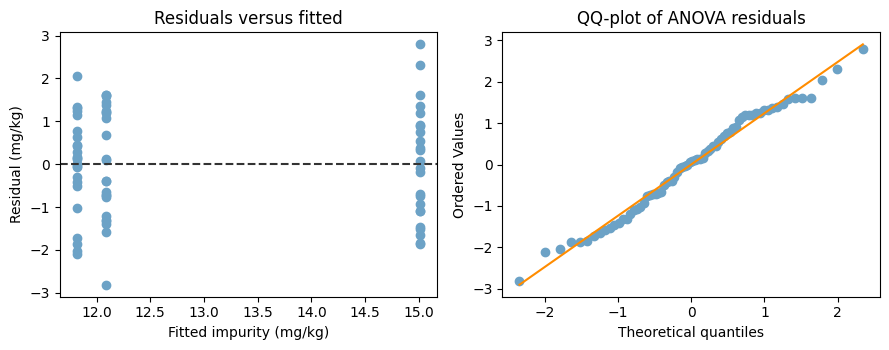

group sample SDs (mg/kg):
 supplier
A    1.113975
B    1.319419
C    1.276602
Name: std, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
axes[0].scatter(model.fittedvalues, model.resid, color="#6CA2C6")
axes[0].axhline(0, color="0.2", linestyle="--")
axes[0].set_xlabel("Fitted impurity (mg/kg)")
axes[0].set_ylabel("Residual (mg/kg)")
axes[0].set_title("Residuals versus fitted")
probplot(model.resid, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_markerfacecolor("#6CA2C6")
axes[1].get_lines()[0].set_markeredgecolor("#6CA2C6")
axes[1].get_lines()[1].set_color("#FF8C00")
axes[1].set_title("QQ-plot of ANOVA residuals")
plt.tight_layout()
plt.show()
print("group sample SDs (mg/kg):\n", summary["std"])


The group SDs and residual plots decide whether the common-variance model is credible. We do not use a preliminary variance test as an automatic switch.

Welch's ANOVA is shown as the unequal-variance alternative, not as a licence to run Tukey afterwards.


In [6]:
welch = anova_oneway(
    df["impurity_mg_kg"],
    groups=df["supplier"],
    use_var="unequal",
)
print(welch)


statistic = 46.17072787428327
pvalue = 1.0629783554620107e-11
df = (2.0, np.float64(45.73528181149318))
df_num = 2.0
df_denom = 45.73528181149318
nobs_t = 72.0
n_groups = 3
means = [11.81733333 15.01516667 12.09166667]
nobs = [24. 24. 24.]
vars_ = [1.24094014 1.74086719 1.62971371]
use_var = unequal
welch_correction = True
tuple = (np.float64(46.17072787428327), np.float64(1.0629783554620107e-11))


### Tukey HSD after a classical omnibus test

If the classical $F$ test is relevant and significant, identify pairs with Tukey HSD. Comparison order: B versus A, C versus A, C versus B, as reported by the software; keep that order in the write-up.


In [7]:
tukey = pairwise_tukeyhsd(df["impurity_mg_kg"], df["supplier"], alpha=0.05)
print(tukey.summary())


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B   3.1978    0.0  2.3405  4.0551   True
     A      C   0.2743 0.7247  -0.583  1.1316  False
     B      C  -2.9235    0.0 -3.7808 -2.0662   True
----------------------------------------------------


Pause: if Tukey does not distinguish A and C, have we **proved** $\mu_A=\mu_C$?

## 4. Interpretation

Follow the Chapter 9 seven-step order: population, unit, response, factor; sampling and independence; group $n$, means, SDs, plot; classical versus Welch; omnibus $F$, df, $p$, $\eta^2$; Tukey intervals if needed; differences in mg/kg, practical importance, and design limits.

These samples describe the tested lots. A causal claim that “switching supplier B reduces impurity” needs a design that rules out batch, handling, and measurement differences.

## 5. Common mistakes / things to notice

- Three unadjusted pairwise $t$-tests among three groups.
- Stopping after “ANOVA was significant” when the question is *which* supplier.
- QQ-plotting the pooled raw $y$ instead of the residuals.
- Combining Welch’s ANOVA with ordinary Tukey intervals.
- Interpreting $\eta^2$ as the probability that supplier determines a sample.
- Treating a non-significant Tukey pair as proof of equal means.

**Conclusion:** Use one-way ANOVA to test a single global claim about three supplier means, diagnose the **errors**, and use Tukey HSD to locate pairwise differences in mg/kg with family-wise control. Report $\eta^2$ as a sample description and keep causation for a design that supports it.
